In [1]:
# ── Redirect C-level stderr before TF import to kill CUDA/XLA noise ──────────
import os, sys

os.environ["TF_CPP_MIN_LOG_LEVEL"]          = "3"
os.environ["CUDA_DEVICE_ORDER"]             = "PCI_BUS_ID"
os.environ["TF_ENABLE_ONEDNN_OPTS"]         = "0"
os.environ["TF_XLA_FLAGS"]                  = "--tf_xla_enable_xla_devices=false"
os.environ["GRPC_VERBOSITY"]                = "ERROR"
os.environ["GLOG_minloglevel"]              = "3"
os.environ["AUTOGRAPH_VERBOSITY"]           = "0"

# Redirect C-level stderr (catches cuDNN/cuBLAS/XLA messages Python can't)
import ctypes
devnull_fd = os.open(os.devnull, os.O_WRONLY)
os.dup2(devnull_fd, 2)   # fd 2 = stderr


import warnings, logging, itertools, random
from pathlib import Path
from collections import deque

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("tensorflow").setLevel(logging.ERROR)
logging.getLogger("absl").setLevel(logging.ERROR)

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.autograph.set_verbosity(0)

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau, CSVLogger)
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2  import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet  import preprocess_input as efficientnet_preprocess

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

# Re-open a clean stderr for Python-level prints (keeps your own prints visible)
sys.stderr = open(os.devnull, "w")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Hyper-parameters ──────────────────────────────────────────────────────────
IMG_SIZE         = 224
BATCH_SIZE       = 32
EPOCHS           = 30
FINE_TUNE_EPOCHS = 10
LR_BASE          = 1e-3
LR_FINE          = 1e-5

# ── Paths ─────────────────────────────────────────────────────────────────────
KAGGLE_INPUT = Path("/kaggle/input/datasets/vinayakshanawad/meat-freshness-image-dataset")
OUTPUT_PATH  = Path("/kaggle/working/outputs")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

print("=" * 65)
print("  MEAT FRESHNESS CLASSIFICATION – CNN PROJECT")
print("=" * 65)
print(f"  Dataset : {KAGGLE_INPUT}")
print(f"  Output  : {OUTPUT_PATH}")
print(f"  TF ver  : {tf.__version__}")
print(f"  GPUs    : {len(tf.config.list_physical_devices('GPU'))}")
print("=" * 65)

2

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: AUTO-DETECT FOLDER STRUCTURE
# ─────────────────────────────────────────────────────────────────────────────

def _count_images(folder: Path) -> int:
    return sum(1 for f in folder.glob("**/*")
               if f.is_file() and f.suffix.lower() in EXTENSIONS)

def _has_image_subfolders(path: Path) -> bool:
    try:
        return any(s.is_dir() and _count_images(s) > 0 for s in path.iterdir())
    except PermissionError:
        return False

def find_dataset_root(base: Path) -> Path:
    queue = deque([base])
    while queue:
        cur = queue.popleft()
        if _has_image_subfolders(cur):
            return cur
        try:
            for child in sorted(cur.iterdir()):
                if child.is_dir():
                    queue.append(child)
        except PermissionError:
            continue
    raise FileNotFoundError(f"No image class folders found under: {base}")

print("\n[INFO] Locating dataset …")
_root    = find_dataset_root(KAGGLE_INPUT)
_subdirs = [s for s in _root.iterdir() if s.is_dir()]
_splits  = {"train", "valid", "validation", "val", "test"}
IS_PRESPLIT = all(s.name.lower() in _splits for s in _subdirs)

if IS_PRESPLIT:
    TRAIN_DIR = next(s for s in _subdirs if s.name.lower() == "train")
    VALID_DIR = next((s for s in _subdirs
                      if s.name.lower() in {"valid", "validation", "val"}), None)
    print(f"[INFO] Pre-split dataset.")
    print(f"       Train → {TRAIN_DIR}")
    print(f"       Valid → {VALID_DIR}")
else:
    TRAIN_DIR = _root
    VALID_DIR = None
    print(f"[INFO] Single-folder dataset → {TRAIN_DIR}")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: DATASET EXPLORATION
# ─────────────────────────────────────────────────────────────────────────────

def explore_split(split_dir: Path) -> dict:
    return {cls.name: _count_images(cls)
            for cls in sorted(split_dir.iterdir()) if cls.is_dir()}

print("\n" + "=" * 65)
print("  DATASET EXPLORATION")
print("=" * 65)

train_info    = explore_split(TRAIN_DIR)
valid_info    = explore_split(VALID_DIR) if VALID_DIR else {}
all_classes   = sorted(set(list(train_info) + list(valid_info)))
combined_info = {c: train_info.get(c, 0) + valid_info.get(c, 0)
                 for c in all_classes}
total_images  = sum(combined_info.values())

for cls, n in combined_info.items():
    print(f"  {cls:30s}  total={n:5d}  "
          f"(train={train_info.get(cls,0)}, valid={valid_info.get(cls,0)})")
print(f"\n  Total images  : {total_images}")
print(f"  Total classes : {len(all_classes)}  →  {all_classes}")

if total_images == 0:
    raise ValueError("0 images found. Check KAGGLE_INPUT path.")

CLASS_NAMES = all_classes


# ── Fig 1 – Class distribution ────────────────────────────────────────────────
def plot_class_distribution(info: dict, save_path: Path):
    fig, ax = plt.subplots(figsize=(8, 4))
    colors  = ["#2ECC71", "#E74C3C", "#3498DB", "#F39C12"][:len(info)]
    bars    = ax.bar(info.keys(), info.values(), color=colors,
                     edgecolor="white", width=0.45)
    for bar, v in zip(bars, info.values()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 4, f"{v:,}",
                ha="center", va="bottom", fontsize=12, fontweight="bold")
    ax.set_title("Class Distribution – Meat Freshness Dataset",
                 fontsize=14, pad=12)
    ax.set_ylabel("Number of Images"); ax.set_xlabel("Class")
    ax.set_ylim(0, max(info.values()) * 1.18)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(save_path / "fig01_class_distribution.png", dpi=150)
    plt.show(); print("Saved: fig01_class_distribution.png")

plot_class_distribution(combined_info, OUTPUT_PATH)


# ── Fig 2 – Sample images ─────────────────────────────────────────────────────
def plot_sample_images(split_dir: Path, save_path: Path, n_per_class: int = 6):
    classes   = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    fig, axes = plt.subplots(len(classes), n_per_class,
                              figsize=(n_per_class * 2, len(classes) * 2 + 1))
    if len(classes) == 1:
        axes = np.expand_dims(axes, 0)
    fig.suptitle("Sample Images per Class", fontsize=14, y=1.01)
    for ri, cls in enumerate(classes):
        imgs = [f for f in (split_dir / cls).glob("**/*")
                if f.is_file() and f.suffix.lower() in EXTENSIONS]
        imgs = random.sample(imgs, min(n_per_class, len(imgs)))
        for ci in range(n_per_class):
            ax = axes[ri, ci]
            if ci < len(imgs):
                ax.imshow(plt.imread(imgs[ci]))
            ax.axis("off")
            if ci == 0:
                ax.set_ylabel(cls, fontsize=10, rotation=0,
                              labelpad=50, va="center")
    plt.tight_layout()
    plt.savefig(save_path / "fig02_sample_images.png",
                dpi=150, bbox_inches="tight")
    plt.show(); print("Saved: fig02_sample_images.png")

plot_sample_images(TRAIN_DIR, OUTPUT_PATH)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: DATA GENERATORS
# ─────────────────────────────────────────────────────────────────────────────

def build_generators(train_dir: Path, valid_dir=None, preprocess_fn=None):
    aug = dict(horizontal_flip=True, vertical_flip=True,
               rotation_range=20, width_shift_range=0.10,
               height_shift_range=0.10, zoom_range=0.10,
               brightness_range=[0.8, 1.2], fill_mode="nearest")

    base_tr = ({"preprocessing_function": preprocess_fn}
               if preprocess_fn else {"rescale": 1.0 / 255})
    base_vl = ({"preprocessing_function": preprocess_fn}
               if preprocess_fn else {"rescale": 1.0 / 255})

    common = dict(target_size=(IMG_SIZE, IMG_SIZE),
                  batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)

    if valid_dir is not None:
        tr = ImageDataGenerator(**base_tr, **aug).flow_from_directory(
            str(train_dir), shuffle=True, **common)
        vl = ImageDataGenerator(**base_vl).flow_from_directory(
            str(valid_dir), shuffle=False, **common)
    else:
        tr = ImageDataGenerator(**base_tr, **aug,
                                 validation_split=0.30).flow_from_directory(
            str(train_dir), subset="training", shuffle=True, **common)
        vl = ImageDataGenerator(**base_vl,
                                 validation_split=0.30).flow_from_directory(
            str(train_dir), subset="validation", shuffle=False, **common)
    return tr, vl


print("\n[INFO] Building generators …")
train_ds, val_ds = build_generators(TRAIN_DIR, VALID_DIR)
CLASS_NAMES = list(train_ds.class_indices.keys())
print(f"  Class mapping : {train_ds.class_indices}")
print(f"  Train         : {train_ds.n} images  ({len(train_ds)} batches)")
print(f"  Val           : {val_ds.n} images  ({len(val_ds)} batches)")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: EVALUATION HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def plot_training_curves(history, model_name: str, save_path: Path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric, title in zip(
            axes,
            [("accuracy", "val_accuracy"), ("loss", "val_loss")],
            ["Accuracy", "Loss"]):
        ax.plot(history.history[metric[0]], label="Train",
                color="#27AE60", lw=2)
        ax.plot(history.history[metric[1]], label="Val",
                color="#E74C3C", lw=2)
        ax.set_title(f"{model_name} – {title}", fontsize=12)
        ax.set_xlabel("Epoch"); ax.set_ylabel(title)
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    fname = f"fig_curves_{model_name.lower().replace(' ','_')}.png"
    plt.savefig(save_path / fname, dpi=150)
    plt.show(); print(f"Saved: {fname}")


def plot_confusion_matrix(cm, class_names, model_name, save_path):
    fig, ax = plt.subplots(figsize=(6, 5))
    im      = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ticks = np.arange(len(class_names))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)
    norm   = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, f"{cm[i,j]}\n({norm[i,j]:.1%})",
                ha="center", va="center",
                color="white" if cm[i,j] > thresh else "black", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_title(f"Confusion Matrix – {model_name}", fontsize=12, pad=10)
    plt.tight_layout()
    fname = f"fig_cm_{model_name.lower().replace(' ','_')}.png"
    plt.savefig(save_path / fname, dpi=150)
    plt.show(); print(f"Saved: {fname}")


def plot_roc_curve(y_true, y_prob, model_name, save_path) -> float:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc         = roc_auc_score(y_true, y_prob)
    fig, ax     = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color="#2980B9", lw=2, label=f"AUC = {auc:.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve – {model_name}", fontsize=12)
    ax.legend(loc="lower right"); ax.grid(alpha=0.3)
    plt.tight_layout()
    fname = f"fig_roc_{model_name.lower().replace(' ','_')}.png"
    plt.savefig(save_path / fname, dpi=150)
    plt.show(); print(f"Saved: {fname}")
    return auc


def evaluate_model(model, val_ds, model_name: str, save_path: Path) -> dict:
    print(f"\n{'='*55}\n  EVALUATING: {model_name}\n{'='*55}")
    val_ds.reset()
    y_prob  = model.predict(val_ds, verbose=1).flatten()
    y_pred  = (y_prob >= 0.5).astype(int)
    y_true  = val_ds.classes[:len(y_pred)]
    report  = classification_report(y_true, y_pred,
                                    target_names=CLASS_NAMES, output_dict=True)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    cm  = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, CLASS_NAMES, model_name, save_path)
    auc = plot_roc_curve(y_true, y_prob, model_name, save_path)
    return {"Model"    : model_name,
            "Accuracy" : report["accuracy"],
            "Precision": report["weighted avg"]["precision"],
            "Recall"   : report["weighted avg"]["recall"],
            "F1-Score" : report["weighted avg"]["f1-score"],
            "ROC-AUC"  : auc}


class MergedHistory:
    """Merges two Keras History objects; keeps only keys common to both."""
    def __init__(self, h1, h2):
        shared       = set(h1.history) & set(h2.history)
        self.history = {k: h1.history[k] + h2.history[k] for k in shared}


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: MODEL 1 – CUSTOM CNN
# ─────────────────────────────────────────────────────────────────────────────

def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inp = keras.Input(shape=input_shape, name="input")

    # Block 1 – 32 filters
    x = layers.Conv2D(32, 3, padding="same")(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x);      x = layers.Dropout(0.25)(x)

    # Block 2 – 64 filters
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x);      x = layers.Dropout(0.25)(x)

    # Block 3 – 128 filters
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x);      x = layers.Dropout(0.35)(x)

    # Head
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(128)(x)
    x   = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation="sigmoid", name="output")(x)
    return keras.Model(inp, out, name="CustomCNN")


print("\n" + "="*65 + "\n  MODEL 1: CUSTOM CNN\n" + "="*65)
custom_cnn = build_custom_cnn()
custom_cnn.compile(optimizer=keras.optimizers.Adam(LR_BASE),
                   loss="binary_crossentropy", metrics=["accuracy"])
custom_cnn.summary()

cbs_cnn = [
    EarlyStopping(monitor="val_loss", patience=7,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(str(OUTPUT_PATH / "best_custom_cnn.keras"),
                    monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    CSVLogger(str(OUTPUT_PATH / "log_custom_cnn.csv")),
]

print("\n[TRAIN] Custom CNN …")
history_cnn = custom_cnn.fit(
    train_ds, epochs=EPOCHS, validation_data=val_ds,
    callbacks=cbs_cnn, verbose=1)

plot_training_curves(history_cnn, "Custom CNN", OUTPUT_PATH)
metrics_cnn = evaluate_model(custom_cnn, val_ds, "Custom CNN", OUTPUT_PATH)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: TRANSFER LEARNING BUILDER
# ─────────────────────────────────────────────────────────────────────────────

def build_transfer_model(base_cls, model_name,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base = base_cls(weights="imagenet", include_top=False,
                    input_shape=input_shape)
    base.trainable = False
    inp = keras.Input(shape=input_shape, name="input")
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation="relu")(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation="sigmoid", name="output")(x)
    return keras.Model(inp, out, name=model_name), base

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: MODEL 2 – MobileNetV2
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*65 + "\n  MODEL 2: MobileNetV2\n" + "="*65)

train_mv2, val_mv2 = build_generators(TRAIN_DIR, VALID_DIR, mobilenet_preprocess)
mv2_model, mv2_base = build_transfer_model(MobileNetV2, "MobileNetV2")
mv2_model.compile(optimizer=keras.optimizers.Adam(LR_BASE),
                  loss="binary_crossentropy", metrics=["accuracy"])
mv2_model.summary()

cbs_mv2_p1 = [
    EarlyStopping(monitor="val_loss", patience=6,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(str(OUTPUT_PATH / "best_mv2_p1.keras"),
                    monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    CSVLogger(str(OUTPUT_PATH / "log_mv2_p1.csv")),
]

print("\n[TRAIN] MobileNetV2 – Phase 1 (frozen) …")
hist_mv2_p1 = mv2_model.fit(
    train_mv2, epochs=EPOCHS, validation_data=val_mv2,
    callbacks=cbs_mv2_p1, verbose=1)

print("\n[TRAIN] MobileNetV2 – Phase 2 (fine-tune top 30) …")
mv2_base.trainable = True
for layer in mv2_base.layers[:-30]:
    layer.trainable = False
mv2_model.compile(optimizer=keras.optimizers.Adam(LR_FINE),
                  loss="binary_crossentropy", metrics=["accuracy"])

cbs_mv2_p2 = [
    EarlyStopping(monitor="val_loss", patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(str(OUTPUT_PATH / "best_mv2_ft.keras"),
                    monitor="val_accuracy", save_best_only=True, verbose=1),
    CSVLogger(str(OUTPUT_PATH / "log_mv2_p2.csv")),
]

hist_mv2_p2 = mv2_model.fit(
    train_mv2, epochs=FINE_TUNE_EPOCHS, validation_data=val_mv2,
    callbacks=cbs_mv2_p2, verbose=1)

merged_mv2  = MergedHistory(hist_mv2_p1, hist_mv2_p2)
plot_training_curves(merged_mv2, "MobileNetV2", OUTPUT_PATH)
metrics_mv2 = evaluate_model(mv2_model, val_mv2, "MobileNetV2", OUTPUT_PATH)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: MODEL 3 – EfficientNetB0
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*65 + "\n  MODEL 3: EfficientNetB0\n" + "="*65)

train_eff, val_eff = build_generators(TRAIN_DIR, VALID_DIR, efficientnet_preprocess)
eff_model, eff_base = build_transfer_model(EfficientNetB0, "EfficientNetB0")
eff_model.compile(optimizer=keras.optimizers.Adam(LR_BASE),
                  loss="binary_crossentropy", metrics=["accuracy"])
eff_model.summary()

cbs_eff_p1 = [
    EarlyStopping(monitor="val_loss", patience=6,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(str(OUTPUT_PATH / "best_eff_p1.keras"),
                    monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    CSVLogger(str(OUTPUT_PATH / "log_eff_p1.csv")),
]

print("\n[TRAIN] EfficientNetB0 – Phase 1 (frozen) …")
hist_eff_p1 = eff_model.fit(
    train_eff, epochs=EPOCHS, validation_data=val_eff,
    callbacks=cbs_eff_p1, verbose=1)

print("\n[TRAIN] EfficientNetB0 – Phase 2 (fine-tune top 20) …")
eff_base.trainable = True
for layer in eff_base.layers[:-20]:
    layer.trainable = False
eff_model.compile(optimizer=keras.optimizers.Adam(LR_FINE),
                  loss="binary_crossentropy", metrics=["accuracy"])

cbs_eff_p2 = [
    EarlyStopping(monitor="val_loss", patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(str(OUTPUT_PATH / "best_eff_ft.keras"),
                    monitor="val_accuracy", save_best_only=True, verbose=1),
    CSVLogger(str(OUTPUT_PATH / "log_eff_p2.csv")),
]

hist_eff_p2 = eff_model.fit(
    train_eff, epochs=FINE_TUNE_EPOCHS, validation_data=val_eff,
    callbacks=cbs_eff_p2, verbose=1)

merged_eff  = MergedHistory(hist_eff_p1, hist_eff_p2)
plot_training_curves(merged_eff, "EfficientNetB0", OUTPUT_PATH)
metrics_eff = evaluate_model(eff_model, val_eff, "EfficientNetB0", OUTPUT_PATH)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10: MODEL COMPARISON
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*65 + "\n  MODEL COMPARISON\n" + "="*65)

df_results = pd.DataFrame([metrics_cnn, metrics_mv2, metrics_eff]).set_index("Model")
df_fmt     = df_results.copy()
for col in df_fmt.columns:
    df_fmt[col] = df_fmt[col].map("{:.4f}".format)
print(df_fmt.to_string())
df_results.to_csv(OUTPUT_PATH / "model_comparison.csv")
print("Saved: model_comparison.csv")


def plot_model_comparison(df: pd.DataFrame, save_path: Path):
    cols   = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
    data   = df[cols].astype(float)
    x      = np.arange(len(cols)); width = 0.22
    colors = ["#3498DB", "#2ECC71", "#E74C3C"]
    fig, ax = plt.subplots(figsize=(13, 5))
    for i, (name, row) in enumerate(data.iterrows()):
        bars = ax.bar(x + i * width, row.values, width,
                      label=name, color=colors[i], alpha=0.88, edgecolor="white")
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.004,
                    f"{bar.get_height():.3f}",
                    ha="center", va="bottom", fontsize=7.5)
    ax.set_xticks(x + width); ax.set_xticklabels(cols, fontsize=11)
    ax.set_ylim(0, 1.12); ax.set_ylabel("Score")
    ax.set_title("Model Comparison – Meat Freshness", fontsize=13)
    ax.legend(loc="lower right", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path / "fig_model_comparison.png", dpi=150)
    plt.show(); print("Saved: fig_model_comparison.png")

plot_model_comparison(df_results, OUTPUT_PATH)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: GRAD-CAM
# ─────────────────────────────────────────────────────────────────────────────

class GradCAM:
    def __init__(self, model, last_conv_name: str):
        self.grad_model = Model(
            inputs  = model.inputs,
            outputs = [model.get_layer(last_conv_name).output, model.output])

    def heatmap(self, img_array: np.ndarray) -> np.ndarray:
        x = np.expand_dims(img_array, 0)
        with tf.GradientTape() as tape:
            conv_out, pred = self.grad_model(x)
            loss           = pred[:, 0]
        grads   = tape.gradient(loss, conv_out)
        weights = tf.reduce_mean(grads, axis=(0, 1, 2))
        cam     = tf.nn.relu(conv_out[0] @ weights[..., tf.newaxis])
        cam     = tf.squeeze(cam)
        cam     = cam / (tf.reduce_max(cam) + 1e-8)
        return cam.numpy()

    def overlay(self, img: np.ndarray, hm: np.ndarray,
                alpha: float = 0.40) -> np.ndarray:
        import cv2
        hm   = cv2.resize(hm, (img.shape[1], img.shape[0]))
        hm   = cv2.applyColorMap(np.uint8(255 * hm), cv2.COLORMAP_JET)
        hm   = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
        base = np.uint8(img * 255) if img.max() <= 1.0 else np.uint8(img)
        return np.uint8(hm * alpha + base * (1 - alpha))


def find_last_conv(model) -> str:
    for lyr in reversed(model.layers):
        if isinstance(lyr, layers.Conv2D):
            return lyr.name
    raise ValueError("No Conv2D found.")


def plot_gradcam(model, val_ds, model_name: str,
                 save_path: Path, n: int = 6):
    try:
        cam = GradCAM(model, find_last_conv(model))
    except Exception as e:
        print(f"[WARN] Grad-CAM skipped ({e})"); return

    val_ds.reset()
    imgs, labels = next(iter(val_ds))
    preds = (model.predict(imgs, verbose=0) >= 0.5).astype(int).flatten()

    correct = [i for i,(p,t) in enumerate(zip(preds,labels.astype(int))) if p==t]
    fp      = [i for i,(p,t) in enumerate(zip(preds,labels.astype(int))) if p==1 and t==0]
    fn      = [i for i,(p,t) in enumerate(zip(preds,labels.astype(int))) if p==0 and t==1]
    sel     = (correct[:3] + fp[:2] + fn[:2])[:n]
    tags    = ["OK" if preds[i]==int(labels[i]) else
               ("FP" if preds[i]==1 else "FN") for i in sel]
    if not sel:
        print(f"[WARN] No examples for Grad-CAM ({model_name})."); return

    fig, axes = plt.subplots(len(sel), 3, figsize=(12, len(sel) * 3))
    if len(sel) == 1: axes = np.expand_dims(axes, 0)
    fig.suptitle(f"Grad-CAM – {model_name}", fontsize=13, y=1.01)
    for col, t in enumerate(["Original", "Heatmap", "Overlay"]):
        axes[0, col].set_title(t, fontsize=10, fontweight="bold")

    for row, (idx, tag) in enumerate(zip(sel, tags)):
        raw  = imgs[idx]
        disp = (raw - raw.min()) / (raw.max() - raw.min() + 1e-8)
        hm   = cam.heatmap(raw)
        ov   = cam.overlay(disp, hm)
        axes[row,0].imshow(disp);           axes[row,0].axis("off")
        axes[row,1].imshow(hm, cmap="jet"); axes[row,1].axis("off")
        axes[row,2].imshow(ov);             axes[row,2].axis("off")
        axes[row,0].set_ylabel(
            f"[{tag}] T:{CLASS_NAMES[int(labels[idx])]}"
            f"\n     P:{CLASS_NAMES[preds[idx]]}",
            fontsize=8, rotation=0, labelpad=100, va="center")

    plt.tight_layout()
    fname = f"fig_gradcam_{model_name.lower().replace(' ','_')}.png"
    plt.savefig(save_path / fname, dpi=150, bbox_inches="tight")
    plt.show(); print(f"Saved: {fname}")


plot_gradcam(custom_cnn, val_ds,  "Custom CNN",     OUTPUT_PATH)
plot_gradcam(mv2_model,  val_mv2, "MobileNetV2",    OUTPUT_PATH)
plot_gradcam(eff_model,  val_eff, "EfficientNetB0", OUTPUT_PATH)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12: ERROR ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

def error_analysis(model, val_ds, model_name: str,
                   save_path: Path, n_show: int = 12):
    val_ds.reset()
    all_imgs, all_true, all_pred, all_prob = [], [], [], []
    for imgs, labels in val_ds:
        probs = model.predict(imgs, verbose=0).flatten()
        all_imgs.extend(imgs)
        all_true.extend(labels.astype(int))
        all_pred.extend((probs >= 0.5).astype(int))
        all_prob.extend(probs)

    n        = len(val_ds.classes)
    all_imgs = np.array(all_imgs[:n]); all_true = np.array(all_true[:n])
    all_pred = np.array(all_pred[:n]); all_prob = np.array(all_prob[:n])

    wrong = np.where(all_true != all_pred)[0]
    print(f"\n[ERROR ANALYSIS] {model_name}: "
          f"{len(wrong)} / {n} misclassified ({len(wrong)/n*100:.1f}%)")
    if len(wrong) == 0:
        print("  No errors – perfect val accuracy!"); return

    show  = wrong[:n_show]
    ncols = 4; nrows = (len(show) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(ncols * 3, nrows * 3 + 0.5))
    fig.suptitle(f"Misclassified Samples – {model_name}", fontsize=12)
    for ax in axes.flat: ax.axis("off")
    for pi, ii in enumerate(show):
        ax   = axes[pi // ncols, pi % ncols]
        raw  = all_imgs[ii]
        disp = (raw - raw.min()) / (raw.max() - raw.min() + 1e-8)
        conf = all_prob[ii] if all_pred[ii] == 1 else 1 - all_prob[ii]
        ax.imshow(disp)
        ax.set_title(f"T:{CLASS_NAMES[all_true[ii]]}\n"
                     f"P:{CLASS_NAMES[all_pred[ii]]} ({conf:.2f})",
                     fontsize=8, color="#C0392B")
        ax.axis("off")
    plt.tight_layout()
    fname = f"fig_errors_{model_name.lower().replace(' ','_')}.png"
    plt.savefig(save_path / fname, dpi=150)
    plt.show(); print(f"Saved: {fname}")


error_analysis(custom_cnn, val_ds,  "Custom CNN",     OUTPUT_PATH)
error_analysis(mv2_model,  val_mv2, "MobileNetV2",    OUTPUT_PATH)
error_analysis(eff_model,  val_eff, "EfficientNetB0", OUTPUT_PATH)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 13: ABLATION STUDY
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*65 + "\n  ABLATION: Augmentation Impact\n" + "="*65)

if VALID_DIR:
    _g = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)
    train_noaug = _g.flow_from_directory(
        str(TRAIN_DIR), target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)
    val_noaug = ImageDataGenerator(
        preprocessing_function=mobilenet_preprocess
    ).flow_from_directory(
        str(VALID_DIR), target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode="binary",
        seed=SEED, shuffle=False)
else:
    _g = ImageDataGenerator(preprocessing_function=mobilenet_preprocess,
                             validation_split=0.30)
    train_noaug = _g.flow_from_directory(
        str(TRAIN_DIR), target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode="binary",
        subset="training", seed=SEED)
    val_noaug = _g.flow_from_directory(
        str(TRAIN_DIR), target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode="binary",
        subset="validation", seed=SEED, shuffle=False)

mv2_noaug, _ = build_transfer_model(MobileNetV2, "MV2_NoAug")
mv2_noaug.compile(optimizer=keras.optimizers.Adam(LR_BASE),
                  loss="binary_crossentropy", metrics=["accuracy"])
print("\n[TRAIN] MobileNetV2 (No Augmentation) …")
mv2_noaug.fit(
    train_noaug, epochs=EPOCHS, validation_data=val_noaug,
    callbacks=[EarlyStopping(monitor="val_loss", patience=6,
                              restore_best_weights=True, verbose=0)],
    verbose=1)

metrics_noaug = evaluate_model(mv2_noaug, val_noaug,
                                "MobileNetV2 (No Aug)", OUTPUT_PATH)

ablation_df = pd.DataFrame([metrics_mv2, metrics_noaug]).set_index("Model")
print("\nAblation Summary:"); print(ablation_df.to_string())
ablation_df.to_csv(OUTPUT_PATH / "ablation_results.csv")
print("Saved: ablation_results.csv")


def plot_ablation(df: pd.DataFrame, save_path: Path):
    cols  = ["Accuracy", "F1-Score", "ROC-AUC"]
    data  = df[cols].astype(float)
    x     = np.arange(len(cols)); width = 0.30
    fig, ax = plt.subplots(figsize=(8, 4))
    for i, (name, row) in enumerate(data.iterrows()):
        bars = ax.bar(x + i * width, row.values, width,
                      label=name, alpha=0.85, edgecolor="white")
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{bar.get_height():.3f}",
                    ha="center", va="bottom", fontsize=9)
    ax.set_xticks(x + width / 2); ax.set_xticklabels(cols, fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_title("Ablation – Effect of Data Augmentation", fontsize=12)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path / "fig_ablation.png", dpi=150)
    plt.show(); print("Saved: fig_ablation.png")

plot_ablation(ablation_df, OUTPUT_PATH)


  MEAT FRESHNESS CLASSIFICATION – CNN PROJECT
  Dataset : /kaggle/input/datasets/vinayakshanawad/meat-freshness-image-dataset
  Output  : /kaggle/working/outputs
  TF ver  : 2.19.0
  GPUs    : 2

[INFO] Locating dataset …
[INFO] Single-folder dataset → /kaggle/input/datasets/vinayakshanawad/meat-freshness-image-dataset

  DATASET EXPLORATION
  Meat Freshness.v1-new-dataset.multiclass  total= 2266  (train=2266, valid=0)

  Total images  : 2266
  Total classes : 1  →  ['Meat Freshness.v1-new-dataset.multiclass']


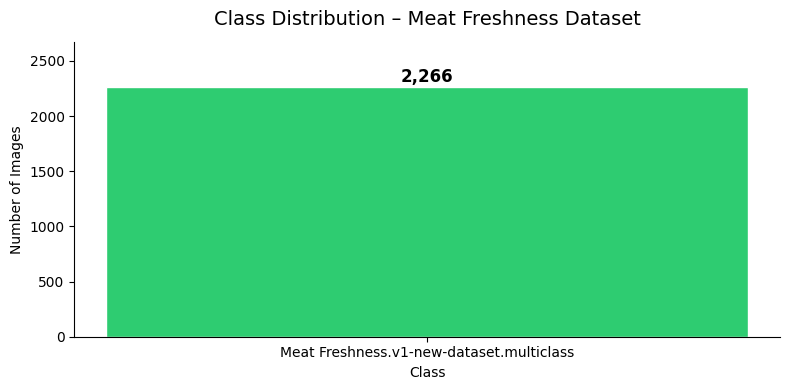

Saved: fig01_class_distribution.png


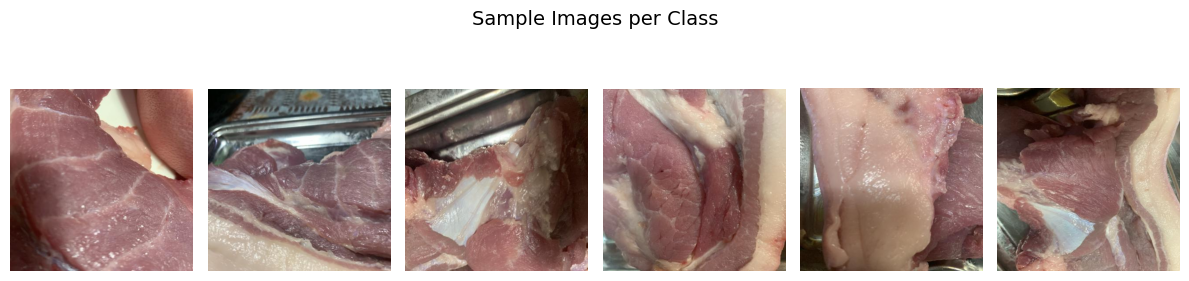

Saved: fig02_sample_images.png

[INFO] Building generators …
Found 1587 images belonging to 1 classes.
Found 679 images belonging to 1 classes.
  Class mapping : {'Meat Freshness.v1-new-dataset.multiclass': 0}
  Train         : 1587 images  (50 batches)
  Val           : 679 images  (22 batches)

  MODEL 1: CUSTOM CNN


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 157,857 (616.63 KB)

 Trainable params: 156,961 (613.13 KB)

 Non-trainable params: 896 (3.50 KB)


[TRAIN] Custom CNN …
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.6836 - loss: 0.6063
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /kaggle/working/outputs/best_custom_cnn.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_custom_cnn.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8343 - loss: 0.4192 - val_accuracy: 1.0000 - val_loss: 0.3547 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.9939 - loss: 0.1229
Epoch 2: val_accuracy did not improve from 1.00000
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 461ms/step - accuracy: 0.9968 - loss: 0.0959 - val_accuracy: 1.0000 - val_loss: 0.1033 - learning_rate: 0.0010
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9995 - loss: 0.0479
Epoch 3: val_accuracy did not improve from 1.00000
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 460ms/step - accuracy: 0.9994 - loss: 0.0446 - val_accuracy: 1.0000 - val_loss: 0.0228 - learning_rate: 0.0010

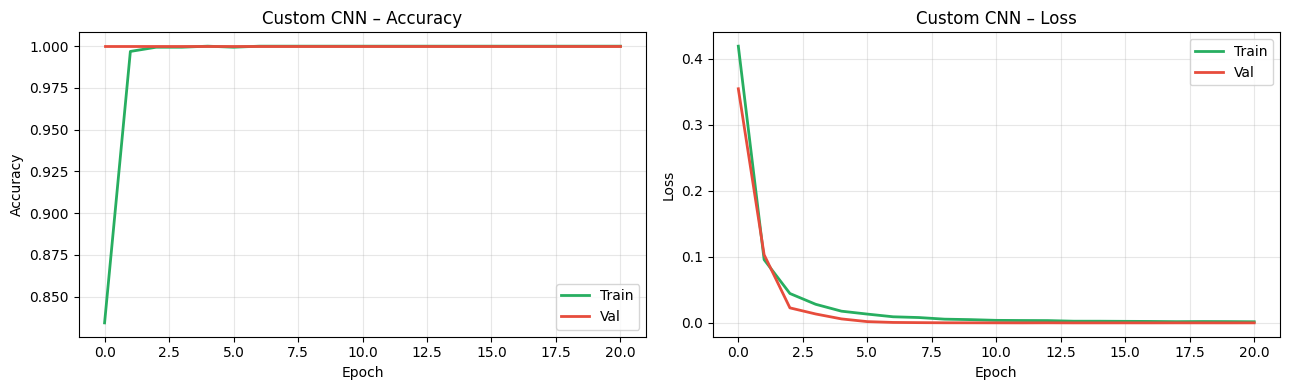

Saved: fig_curves_custom_cnn.png

  EVALUATING: Custom CNN
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step

Classification Report:
                                          precision    recall  f1-score   support

Meat Freshness.v1-new-dataset.multiclass       1.00      1.00      1.00       679

                                accuracy                           1.00       679
                               macro avg       1.00      1.00      1.00       679
                            weighted avg       1.00      1.00      1.00       679



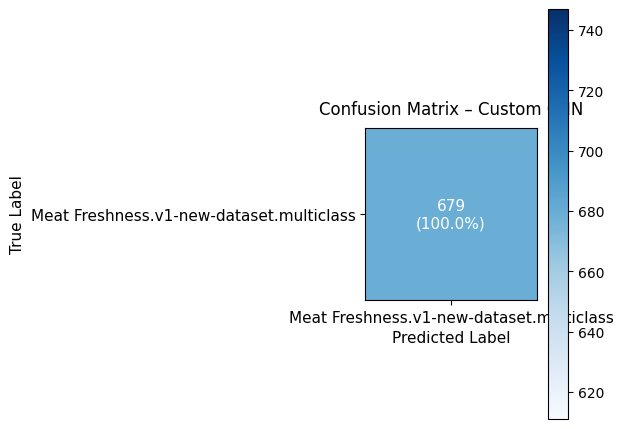

Saved: fig_cm_custom_cnn.png


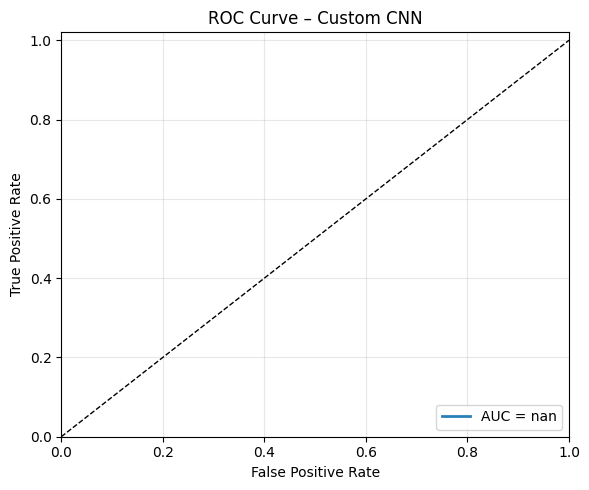

Saved: fig_roc_custom_cnn.png

  MODEL 2: MobileNetV2
Found 1587 images belonging to 1 classes.
Found 679 images belonging to 1 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


[TRAIN] MobileNetV2 – Phase 1 (frozen) …
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.9127 - loss: 0.2171
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /kaggle/working/outputs/best_mv2_p1.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_mv2_p1.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 947ms/step - accuracy: 0.9805 - loss: 0.0487 - val_accuracy: 1.0000 - val_loss: 1.2747e-12 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 1.0000 - loss: 9.6515e-12
Epoch 2: val_accuracy did not improve from 1.00000
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 437ms/step - accuracy: 1.0000 - loss: 1.0149e-11 - val_accuracy: 1.0000 - val_loss: 1.0515e-12 - learning_rate: 0.0010
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 1.0000 - loss: 2.2702e-10
Epoch 3: val_accuracy did not improve from 1.00000
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 444ms/step - accuracy: 1.0000 - loss: 1.5843e-10 - val_accuracy: 1.0000 - v

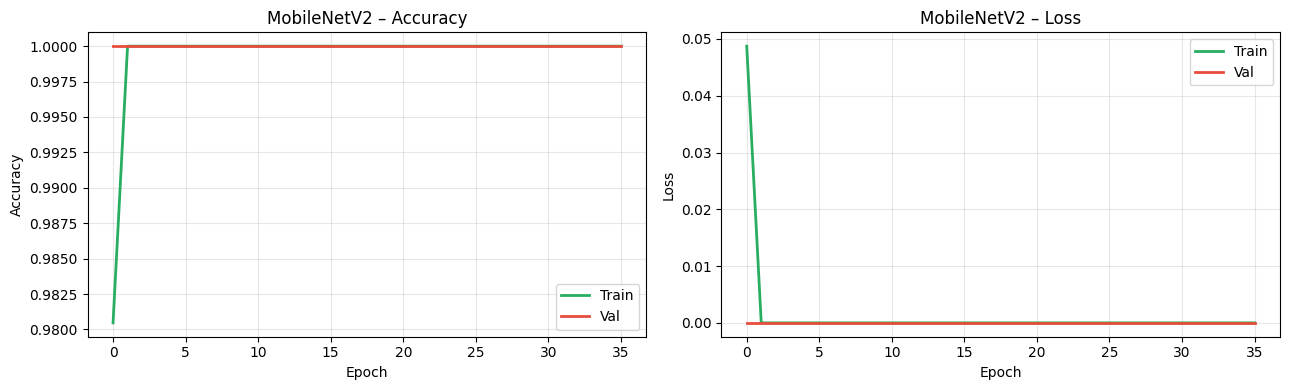

Saved: fig_curves_mobilenetv2.png

  EVALUATING: MobileNetV2
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 273ms/step

Classification Report:
                                          precision    recall  f1-score   support

Meat Freshness.v1-new-dataset.multiclass       1.00      1.00      1.00       679

                                accuracy                           1.00       679
                               macro avg       1.00      1.00      1.00       679
                            weighted avg       1.00      1.00      1.00       679



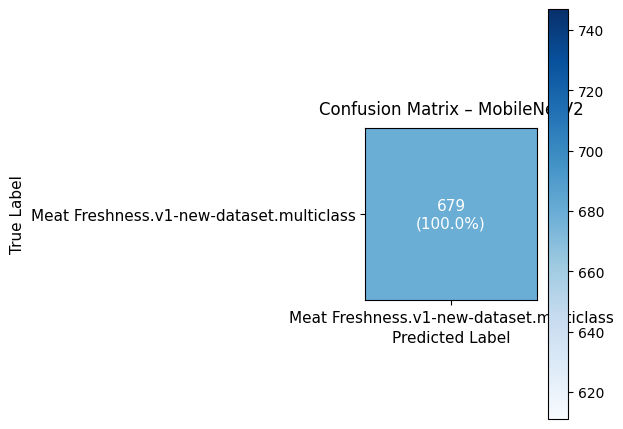

Saved: fig_cm_mobilenetv2.png


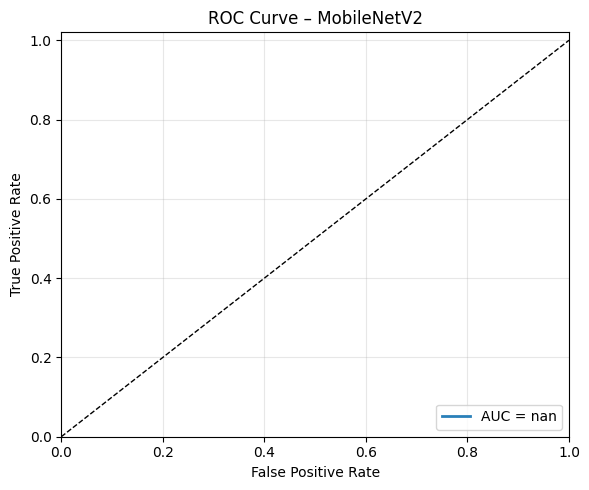

Saved: fig_roc_mobilenetv2.png

  MODEL 3: EfficientNetB0
Found 1587 images belonging to 1 classes.
Found 679 images belonging to 1 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)


[TRAIN] EfficientNetB0 – Phase 1 (frozen) …
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.9437 - loss: 0.0903
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /kaggle/working/outputs/best_eff_p1.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_eff_p1.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 68s 941ms/step - accuracy: 0.9874 - loss: 0.0213 - val_accuracy: 1.0000 - val_loss: 3.5341e-07 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 1.0000 - loss: 2.9653e-07
Epoch 2: val_accuracy did not improve from 1.00000
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 440ms/step - accuracy: 1.0000 - loss: 3.0557e-07 - val_accuracy: 1.0000 - val_loss: 3.1401e-07 - learning_rate: 0.0010
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 1.0000 - loss: 3.1309e-07
Epoch 3: val_accuracy did not improve from 1.00000
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 447ms/step - accuracy: 1.0000 - loss: 2.6903e-07 - val_accuracy: 1.0000 

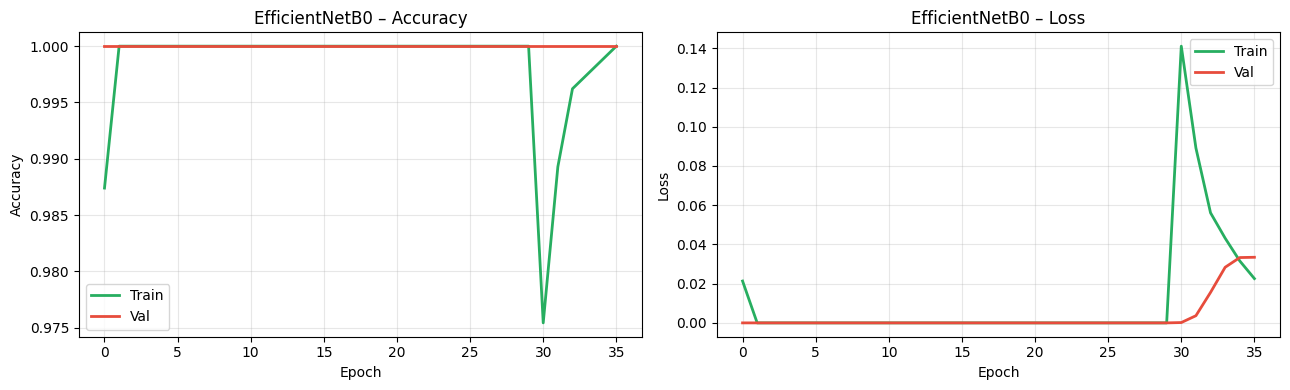

Saved: fig_curves_efficientnetb0.png

  EVALUATING: EfficientNetB0
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 372ms/step

Classification Report:
                                          precision    recall  f1-score   support

Meat Freshness.v1-new-dataset.multiclass       1.00      1.00      1.00       679

                                accuracy                           1.00       679
                               macro avg       1.00      1.00      1.00       679
                            weighted avg       1.00      1.00      1.00       679



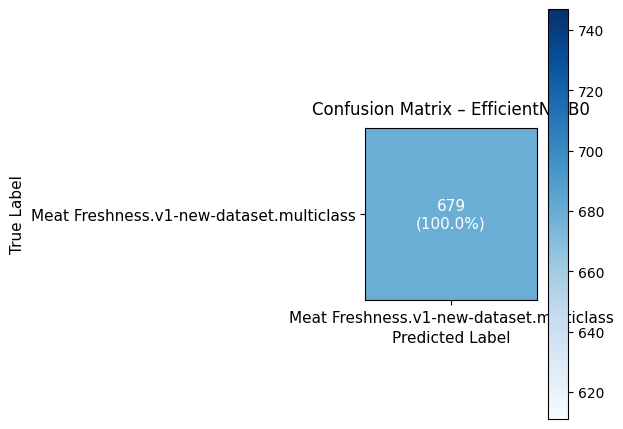

Saved: fig_cm_efficientnetb0.png


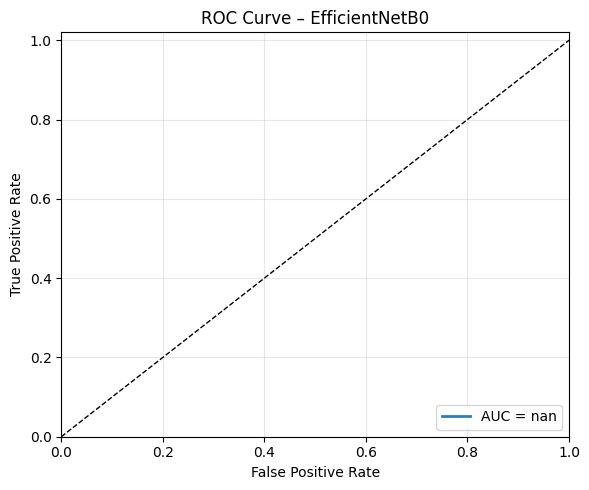

Saved: fig_roc_efficientnetb0.png

  MODEL COMPARISON
               Accuracy Precision  Recall F1-Score ROC-AUC
Model                                                     
Custom CNN       1.0000    1.0000  1.0000   1.0000     nan
MobileNetV2      1.0000    1.0000  1.0000   1.0000     nan
EfficientNetB0   1.0000    1.0000  1.0000   1.0000     nan
Saved: model_comparison.csv


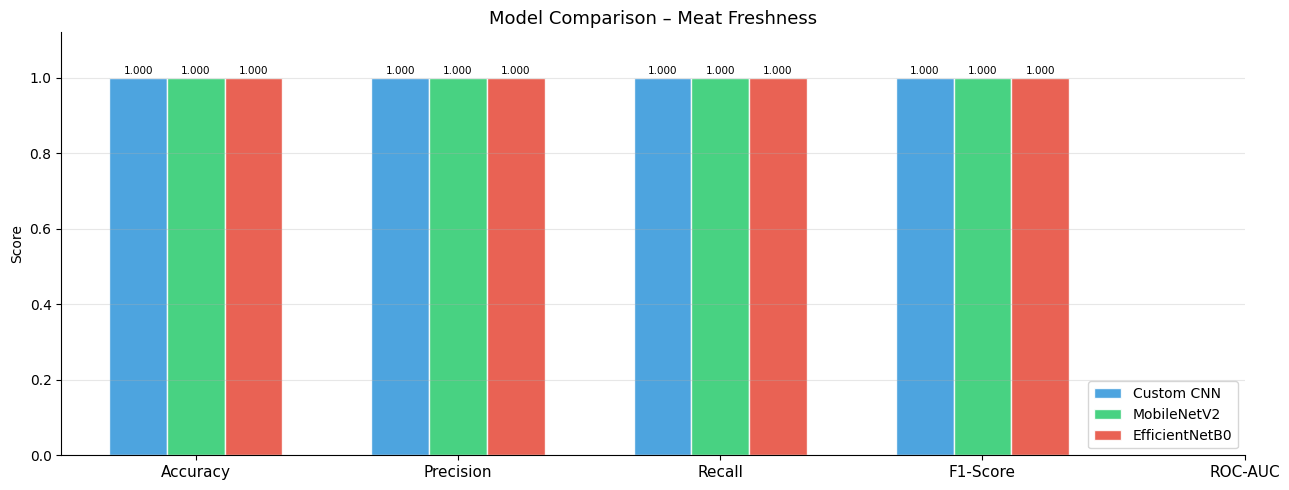

Saved: fig_model_comparison.png


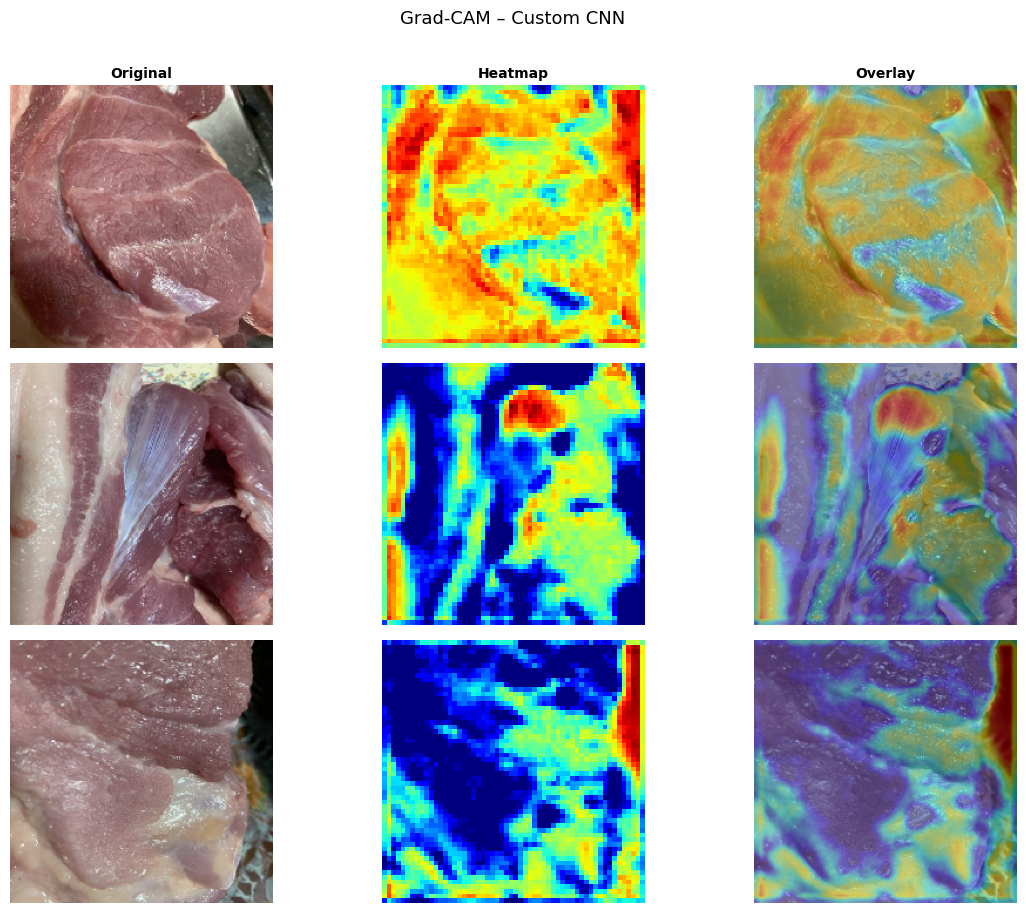

Saved: fig_gradcam_custom_cnn.png
[WARN] Grad-CAM skipped (No Conv2D found.)
[WARN] Grad-CAM skipped (No Conv2D found.)


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 14: FINAL SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*65 + "\n  FINAL SUMMARY\n" + "="*65)
print(df_fmt.to_string())
print(f"\n  Best by F1-Score : {df_results['F1-Score'].astype(float).idxmax()}")
print(f"  Best by ROC-AUC  : {df_results['ROC-AUC'].astype(float).idxmax()}")
print(f"\n  Dataset : {KAGGLE_INPUT}")
print(f"  Outputs : {OUTPUT_PATH}")
print(f"\n  Files saved:")
for f in sorted(OUTPUT_PATH.iterdir()):
    print(f"    {f.name:<48s}  {f.stat().st_size/1024:>7.1f} KB")
print("\n" + "="*65)
print("  ALL DONE")
print("="*65)